<a href="https://colab.research.google.com/github/fboldt/aulas-am-bsi/blob/main/aula24a_regularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[0.59166419 0.66491019] -0.7498512544480382


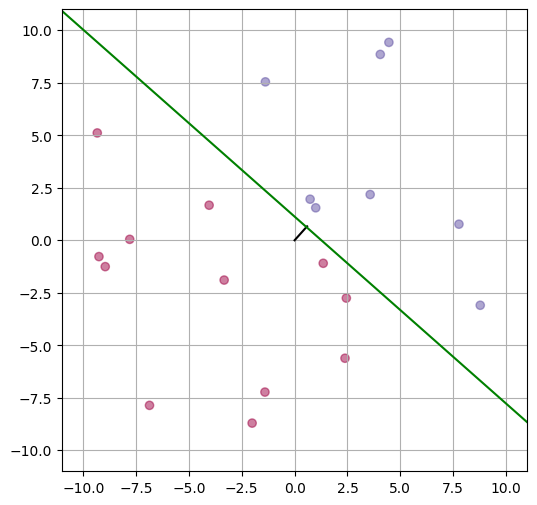

In [145]:
import numpy as np
import matplotlib.pyplot as plt

def generateLinearSeparableDataset(n_samples, weights, bias):
    n_features = len(weights)
    X = np.random.rand(n_samples, n_features)*20-10
    y = np.sign(np.dot(X, weights) + bias)
    return X, y

def plotDataset(X, y, xlim=(-11, 11), ylim=(-11, 11)):
    plt.figure(figsize=(6, 6))
    plt.scatter(X[:, 0], X[:, 1], c=y, marker='o', alpha=0.5, cmap="Spectral")
    plt.xlim(*xlim)
    plt.ylim(*ylim)
    plt.grid(True)

def plotVector(weights):
    xs = [0, weights[0]]
    ys = [0, weights[1]]
    plt.plot(xs, ys, 'k-')

def plotHyperplan(weights, bias):
    xs = np.array([-11, 11])
    ys = -(weights[0]*xs + bias)/weights[1]
    plt.plot(xs, ys, 'g')

weights = np.random.rand(2)*2-1
bias = np.random.rand()*6-3
print(weights, bias)

X, y = generateLinearSeparableDataset(20, weights, bias)
plotDataset(X, y)
plotVector(weights)
plotHyperplan(weights, bias)
plt.show()

In [146]:
from abc import ABC, abstractmethod

class CostFunction(ABC):
    @abstractmethod
    def getCost(self, y, ypred):
        pass
    @abstractmethod
    def getGradient(self, X):
        pass

class WidrowHoff(CostFunction):
  def getCost(self, y, y_pred):
    return np.mean((y - y_pred)**2)
  def getGradient(self, y, y_pred, X):
    return X.T @ (y - y_pred)

class SmoothSurrogate(CostFunction):
  def getCost(self, y, y_pred):
    error = y - np.sign(y_pred)
    return np.sqrt(np.sum(error**2))
  def getGradient(self, y, y_pred, X):
    error = y - np.sign(y_pred)
    return X.T @ error

class LogLikehood(CostFunction):
  def getCost(self, y, y_pred):
    return np.sum(np.maximum(0, 1 - y * y_pred))
  def getGradient(self, y, y_pred, X):
    return X.T @ (y - np.tanh(y_pred))

class HingeLoss(CostFunction):
  def getCost(self, y, y_pred):
    return np.sum(np.maximum(0, 1 - y * y_pred))
  def getGradient(self, y, y_pred, X):
    marginal_errors = (y * y_pred) < 1
    marginal_ys = np.copy(y)
    marginal_ys[~marginal_errors] = 0
    return X.T @ marginal_ys


In [147]:
class TrainingAlgorithm(ABC):
  @abstractmethod
  def getW(self, X, y):
    pass

class GradientDescent(TrainingAlgorithm):
  def __init__(self, max_iter=1000, learning_rate=0.002, cost=WidrowHoff()):
    self.max_iter = max_iter
    self.learning_rate = learning_rate
    self.cost = cost

  def getW(self, X, y):
    w = np.random.uniform(size=(X.shape[1],))
    for _ in range(self.max_iter):
      y_pred = X @ w
      w += self.cost.getGradient(y, y_pred, X) * self.learning_rate
    return w


In [148]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import accuracy_score

def include_bias(X):
  return np.hstack((np.ones((X.shape[0], 1)), X))

class ShallowNeuralNetwork(BaseEstimator, ClassifierMixin):
  def __init__(self, trainingAlgorithm):
    self.trainingAlgorithm = trainingAlgorithm

  def fit(self, X, y):
    X = include_bias(X)
    self.w = self.trainingAlgorithm.getW(X, y)
    return self

  def pre_activation(self, X):
    logits = X @ self.w
    return logits

  def predict(self, X):
    X = include_bias(X)
    logits = self.pre_activation(X)
    y_pred = np.sign(logits)
    return y_pred

model = ShallowNeuralNetwork(GradientDescent())
model.fit(X, y)
y_pred = model.predict(X)
print(f"Accuracy: {accuracy_score(y, y_pred)}")
print(f"Weights: {model.w}")

Accuracy: 1.0
Weights: [-0.09651282  0.10964765  0.09779986]


Cost function: WidrowHoff
Accuracy: 0.95
Weights: [-0.09651282  0.10964765  0.09779986]



<Figure size 500x500 with 0 Axes>

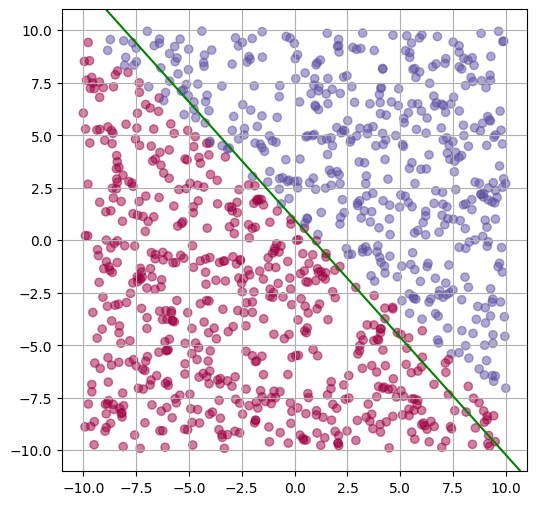

Cost function: SmoothSurrogate
Accuracy: 0.908
Weights: [0.20155175 0.43150983 0.72798651]



<Figure size 500x500 with 0 Axes>

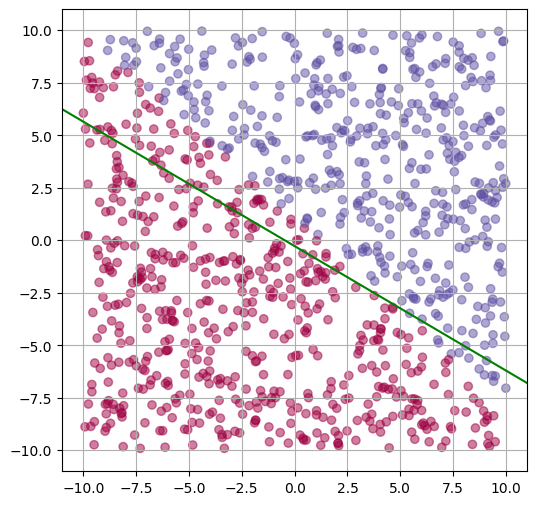

Cost function: LogLikehood
Accuracy: 0.935
Weights: [-0.88491143  0.91286924  1.38621409]



<Figure size 500x500 with 0 Axes>

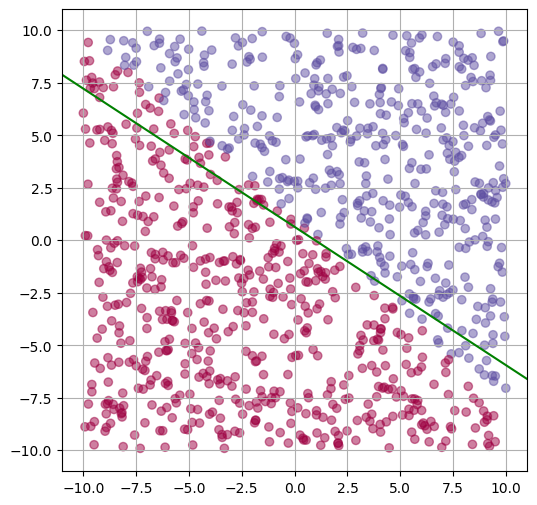

Cost function: HingeLoss
Accuracy: 0.93
Weights: [-0.76250143  0.49917057  0.8394895 ]



<Figure size 500x500 with 0 Axes>

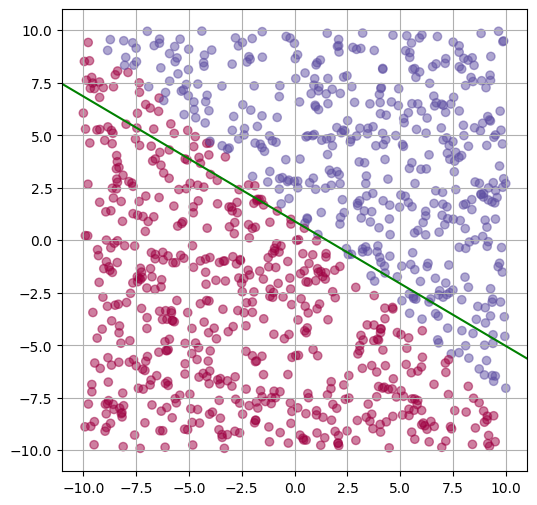

Cost function: WidrowHoff
Accuracy: 0.95

Cost function: SmoothSurrogate
Accuracy: 0.908

Cost function: LogLikehood
Accuracy: 0.935

Cost function: HingeLoss
Accuracy: 0.93



In [149]:
cost_functions = [WidrowHoff(), SmoothSurrogate(), LogLikehood(), HingeLoss()]

X_test, y_test = generateLinearSeparableDataset(1000, weights, bias)
vanilla_accuracies = []

for cost_function in cost_functions:
  model = ShallowNeuralNetwork(GradientDescent(cost=cost_function))
  model.fit(X, y)
  y_pred = model.predict(X_test)
  cost_function_name = cost_function.__class__.__name__
  accuracy = accuracy_score(y_test, y_pred)
  vanilla_accuracies.append((cost_function_name,accuracy))
  print(f"Cost function: {cost_function_name}")
  print(f"Accuracy: {accuracy}")
  print(f"Weights: {model.w}")
  print()
  plt.figure(figsize=(5,5))
  y_pred = model.predict(X_test)
  plotDataset(X_test, y_test)
  plotHyperplan(model.w[1:], model.w[0])
  plt.show()

for cost_function_name, accuracy in vanilla_accuracies:
  print(f"Cost function: {cost_function_name}")
  print(f"Accuracy: {accuracy}")
  print()

In [150]:
class GradientDescent(TrainingAlgorithm):
  def __init__(self, max_iter=1000,
               learning_rate=0.002,
               cost=WidrowHoff(),
               regularization=0):
    self.max_iter = max_iter
    self.learning_rate = learning_rate
    self.cost = cost
    self.regularization = regularization

  def getW(self, X, y):
    w = np.random.uniform(size=(X.shape[1],))
    for _ in range(self.max_iter):
      y_pred = X @ w
      w *= 1 - self.learning_rate * self.regularization
      w += self.cost.getGradient(y, y_pred, X) * self.learning_rate
    return w


Cost function: WidrowHoff
Accuracy: 0.937
Weights: [-0.01799771  0.09771337  0.08362251]



<Figure size 500x500 with 0 Axes>

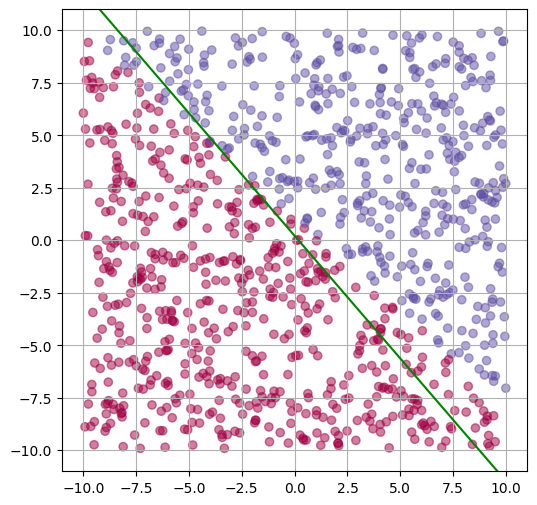

Cost function: SmoothSurrogate
Accuracy: 0.934
Weights: [9.50826306e-99 6.31116550e-98 8.74176793e-98]



<Figure size 500x500 with 0 Axes>

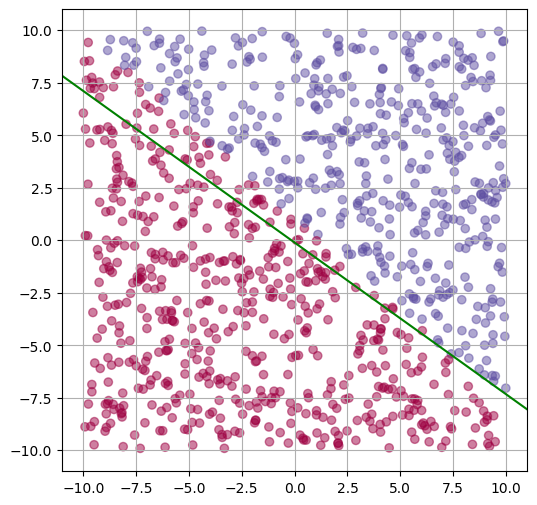

Cost function: LogLikehood
Accuracy: 0.95
Weights: [-0.02074419  0.13885949  0.13133944]



<Figure size 500x500 with 0 Axes>

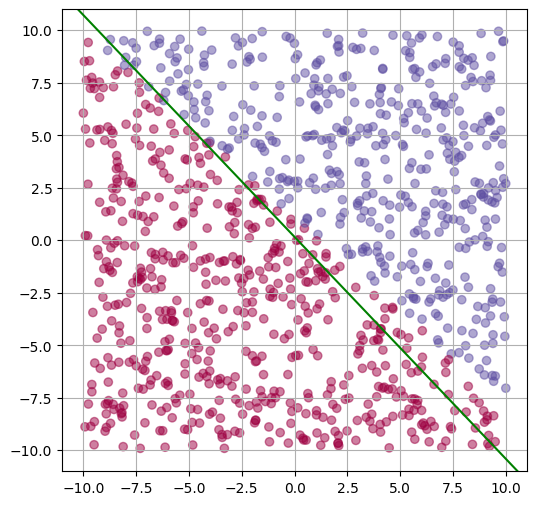

Cost function: HingeLoss
Accuracy: 0.949
Weights: [-0.01813401  0.16860368  0.16420146]



<Figure size 500x500 with 0 Axes>

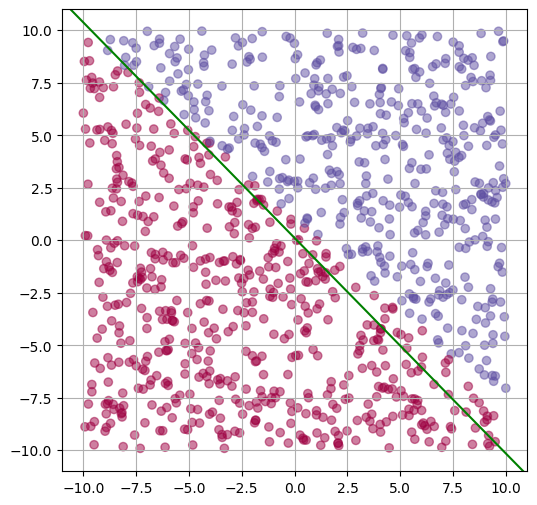

Cost function: WidrowHoff
Accuracy: 0.937

Cost function: SmoothSurrogate
Accuracy: 0.934

Cost function: LogLikehood
Accuracy: 0.95

Cost function: HingeLoss
Accuracy: 0.949



In [151]:
regularized_accuracies = []

for cost_function in cost_functions:
  model = ShallowNeuralNetwork(GradientDescent(cost=cost_function, regularization=100))
  model.fit(X, y)
  y_pred = model.predict(X_test)
  cost_function_name = cost_function.__class__.__name__
  accuracy = accuracy_score(y_test, y_pred)
  regularized_accuracies.append((cost_function_name,accuracy))
  print(f"Cost function: {cost_function_name}")
  print(f"Accuracy: {accuracy}")
  print(f"Weights: {model.w}")
  print()
  plt.figure(figsize=(5,5))
  y_pred = model.predict(X_test)
  plotDataset(X_test, y_test)
  plotHyperplan(model.w[1:], model.w[0])
  plt.show()

for cost_function_name, accuracy in regularized_accuracies:
  print(f"Cost function: {cost_function_name}")
  print(f"Accuracy: {accuracy}")
  print()

In [152]:
for vanilla_accuracy, regularized_accuracy in zip(vanilla_accuracies, regularized_accuracies):
  print(f"Cost function: {vanilla_accuracy[0]}")
  print(f"Vanilla accuracy: {vanilla_accuracy[1]}")
  print(f"Regularized accuracy: {regularized_accuracy[1]}")
  print()

Cost function: WidrowHoff
Vanilla accuracy: 0.95
Regularized accuracy: 0.937

Cost function: SmoothSurrogate
Vanilla accuracy: 0.908
Regularized accuracy: 0.934

Cost function: LogLikehood
Vanilla accuracy: 0.935
Regularized accuracy: 0.95

Cost function: HingeLoss
Vanilla accuracy: 0.93
Regularized accuracy: 0.949

